In [8]:
import sys
sys.path.append('../CoupledQuantumSystems/')
from systems import *
import pickle

In [6]:
max_ql = 13
max_ol = 15
EJ = 4
EC = EJ/2.7
EL = EJ/45
Er = 10.38695526

g = 0.2
w_d = 10.389507326769158
amp = 0.005
tot_time =100

tlist = np.linspace(0, tot_time, tot_time)
system  =  FluxoniumOscillatorSystem(
                EJ = EJ,
                EC = EC,
                EL = EL,
                Er = Er,
                g_strength = g,
                qubit_level = max_ql,
                osc_level = max_ol,
                products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
                computaional_states = '0,2',
                )

In [9]:
with open('sesolve_large_dim_a005.pkl', 'rb') as file:
    results = pickle.load(file)

(0.0, 470.0)

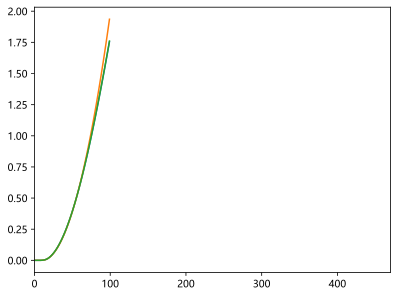

In [10]:
for i in [0,1,2]:
    plt.plot(results[i].expect[1])
plt.xlim(0,470)

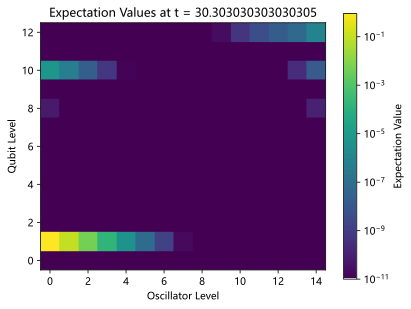

In [14]:
from visualization import *
plot_heatmap(results[1],30,system.product_to_dressed,max_ql,max_ol,LogNorm())

In [15]:
lists = []
for ql in [0 ,1,2]:
    pop_list = []
    for t_idx in tqdm(range(len(tlist))[::10], desc = "t loop"):
        dm = results[ql].states[t_idx]
        pop_sum = 1
        for q in range(max_ql):
            if q == ql:
                for o in range(max_ol):
                    product_state = (q, o)
                    dressed_state = system.product_to_dressed[product_state]
                    basis_state = system.truncate_function(qutip.basis(max_ql * max_ol,  dressed_state))
                    expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                    pop_sum -= expectation_value

        pop_list.append(pop_sum)
    lists.append(pop_list)


t loop: 100%|██████████| 10/10 [00:00<00:00, 83.90it/s]


Text(0.5, 0, 't (ns)')

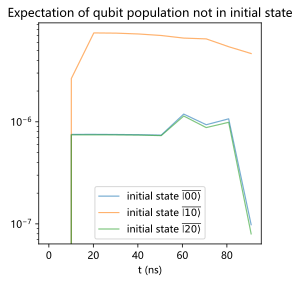

In [17]:
# from utils_models import *
plt.figure(figsize=(4,4))
for ql,pop_list in enumerate(lists): 
    plt.plot(tlist[::10],pop_list,label = rf"initial state $\overline{{\left|{ql}0\right>}}$",linewidth =1.2,alpha = 0.6)
plt.yscale('log')
# plt.ylim(1e-6,1)
plt.legend()
# plt.title('expecation of qubit not being in initial state,\n sesolve with 15 level qbt, 40 level osc')
plt.title('Expectation of qubit population not in initial state')
plt.xlabel('t (ns)')

In [19]:
lists = []
for ql in [0,1,2]:
    pops_list = [[] for _ in range(max_ql)]
    for t_idx in tqdm(range(len(tlist))[::10], desc = "t loop"):
        dm = results[ql].states[t_idx]
        for q in range(max_ql):
            sum_at_this_t_for_this_q = 0
            for o in range(system.osc.truncated_dim):
                product_state = (q, o)
                dressed_state = system.product_to_dressed[product_state]
                basis_state = system.truncate_function(qutip.basis(max_ql*max_ol, dressed_state))
                expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                sum_at_this_t_for_this_q += expectation_value
            pops_list[q].append(sum_at_this_t_for_this_q)
    lists.append(pops_list)


t loop: 100%|██████████| 10/10 [00:01<00:00,  7.93it/s]


Text(0.5, 0, 't (ns)')

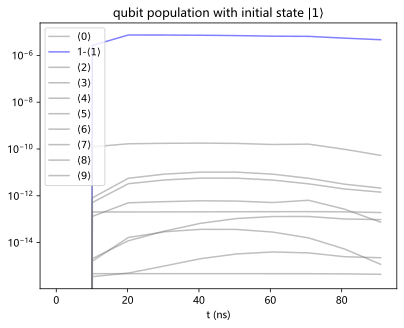

In [22]:
initial_ql = 1

qls = list(range(len(lists[0][0])))
for ql,pop_list in zip(qls,lists[initial_ql]): 
    if ql == initial_ql:
        plt.plot(tlist[::10],1-np.array(pop_list),label = rf"1-$\langle{ql}\rangle$",color='blue',alpha=0.5)
    elif ql != 10:
        plt.plot(tlist[::10],pop_list,label = rf"$\langle{ql}\rangle$",color='grey',alpha=0.5)
    else:
        plt.plot(tlist[::10],pop_list,label = rf"$\langle{ql}\rangle$",color='red',alpha=0.5)


# plt.axvline(x=656, color='k', linestyle='--')

plt.title(rf'qubit population with initial state $|{initial_ql}\rangle$')
plt.yscale('log')
plt.legend()
plt.legend()
plt.xlabel('t (ns)')